In [ ]:
PATH_BioData = "../../../DATASETS/BioData_backup_alex/"

PATH_merge_df = "merged_dataset.csv"
PATH_ESM = PATH_BioData + "esm_embeddings.csv"
PATH_PROT_T5 = PATH_BioData + "prot_embeddings.csv"
PATH_PROST_T5 = PATH_BioData + "prostT5_embeddings.csv"

In [3]:
import pandas as pd

df = pd.read_csv(PATH_merge_df)
print(df.columns)

Index(['accession_code', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl', 'provenance_x',
       'organism', 'sequence', 'seq_length', 'provenance_y', 'class',
       'provenance'],
      dtype='object')


In [23]:
df_esm = pd.read_csv(PATH_ESM)
df_prot_t5 = pd.read_csv(PATH_PROT_T5)
df_prost_t5 = pd.read_csv(PATH_PROST_T5)

print("\n Columns in esm embeddings")
for col in df_esm.columns:
    print(f"Column: {col}")
    print(f"Type: {type(df_esm[col][0])}")

print("\n Columns in prot t5 embeddings")
for col in df_prot_t5.columns:
    print(f"Column: {col}")
    print(f"Type: {type(df_esm[col][0])}")

print("\n Columns in prost t5 embeddings")
for col in df_prost_t5.columns:
    print(f"Column: {col}")
    print(f"Type: {type(df_esm[col][0])}")



 Columns in esm embeddings
Column: accession_code
Type: <class 'str'>
Column: esm_embedding
Type: <class 'str'>

 Columns in prot t5 embeddings
Column: accession_code
Type: <class 'str'>
Column: esm_embedding
Type: <class 'str'>

 Columns in prost t5 embeddings
Column: accession_code
Type: <class 'str'>
Column: esm_embedding
Type: <class 'str'>


In [24]:
import ast

# Convert the 'esm_embedding' column from string to a list of floats for each DataFrame
df_esm['embedding'] = df_esm['esm_embedding'].apply(ast.literal_eval)
df_esm.drop(columns=['esm_embedding'], inplace=True)
df_prot_t5['embedding'] = df_prot_t5['esm_embedding'].apply(ast.literal_eval)
df_prot_t5.drop(columns=['esm_embedding'], inplace=True)
df_prost_t5['embedding'] = df_prost_t5['esm_embedding'].apply(ast.literal_eval)
df_prost_t5.drop(columns=['esm_embedding'], inplace=True)

# Verify the conversion
print(type(df_esm['embedding'][0]))  # Should print <class 'list'>
print(df_esm['embedding'][0])  # Should print the embedding as a list of floats

<class 'list'>
[-0.18701172, -0.17663574, 0.19384766, 0.15600586, 0.16564941, -0.08850098, 0.119140625, 0.06854248, 0.116882324, -0.07116699, 0.10180664, 0.16015625, -0.09472656, 0.120666504, 0.09436035, -0.32055664, 0.19140625, -0.21289062, -0.14135742, 0.15344238, 0.0006465912, -0.03074646, -0.048339844, -0.116882324, 0.029678345, 0.24279785, -0.079711914, 0.10021973, 0.079711914, 0.0993042, 0.036895752, 0.11529541, 0.13696289, -0.07336426, 0.15515137, -0.07409668, 0.026153564, 0.032806396, 0.020370483, 0.021759033, 0.011566162, 0.19091797, -0.041381836, 0.14465332, 0.026657104, 0.056762695, -1.0380859, -0.044403076, -0.2434082, -0.078186035, -0.033081055, -0.058898926, -0.011489868, 0.13000488, -0.12390137, -0.05621338, 0.34936523, -0.01550293, 0.42358398, -0.25952148, -0.029571533, -0.035858154, -4.296875, 0.019485474, 0.020080566, -0.004760742, 0.13879395, -0.12524414, -0.19091797, 0.10321045, 0.005870819, 0.082336426, -0.14685059, 0.16955566, 0.10797119, 0.020324707, 0.09655762, 

In [36]:
key_features = ['accession_code', 'c_max_mbl', 'f_max_mbl', 'p_max_mbl',
       'organism', 'seq_length', 'class']

# Merge the embeddings DataFrames with df to align and order them by 'accession_code'
df_esm_aligned = pd.merge(df[['accession_code']], df_esm, on='accession_code', how='left')
df_prot_t5_aligned = pd.merge(df[['accession_code']], df_prot_t5, on='accession_code', how='left')
df_prost_t5_aligned = pd.merge(df[['accession_code']], df_prost_t5, on='accession_code', how='left')

# Extract only the 'embedding' column after alignment
df_esm_aligned = df_esm_aligned['embedding']
df_prot_t5_aligned = df_prot_t5_aligned['embedding']
df_prost_t5_aligned = df_prost_t5_aligned['embedding']

# Create the organized dictionary
organized_dfs = {
    "Features": df[key_features],  # Add the numerical features from df
    "ESM": df_esm_aligned,
    "Prot-T5": df_prot_t5_aligned,
    "Prost-T5": df_prost_t5_aligned
}

# Verify the structure of the new dictionary
for key, value in organized_dfs.items():
    if key == "Features":
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {value.shape}, {len(value[0]) if len(value) > 0 and value[0] is not None else 'Empty'}")

Features: (1321, 7)
ESM: (1321,), 320
Prot-T5: (1321,), 1024
Prost-T5: (1321,), 1024


In [40]:
import numpy as np

# Convert the embeddings in organized_dfs to 2D NumPy arrays
organized_dfs["ESM"] = np.vstack(organized_dfs["ESM"].dropna().to_numpy())
organized_dfs["Prot-T5"] = np.vstack(organized_dfs["Prot-T5"].dropna().to_numpy())
organized_dfs["Prost-T5"] = np.vstack(organized_dfs["Prost-T5"].dropna().to_numpy())

# Verify the shapes of the embeddings
print(f"ESM shape: {organized_dfs['ESM'].shape}")
print(f"Prot-T5 shape: {organized_dfs['Prot-T5'].shape}")
print(f"Prost-T5 shape: {organized_dfs['Prost-T5'].shape}")

ESM shape: (1321, 320)
Prot-T5 shape: (1321, 1024)
Prost-T5 shape: (1321, 1024)


Ploting with Fade

In [37]:
PATH_SAVE_IMG = "../../../IMGS/df_analysis_2/PCA_UMAP_KMeans2/"

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import umap
from matplotlib import colormaps  # Updated for Matplotlib 3.7+
from matplotlib.lines import Line2D  # For custom legend

def _reduce_embeddings_3d(method, embeddings, n_components=3):
    """Helper function to reduce embeddings to 3D."""
    if method == "PCA":
        reducer = PCA(n_components=n_components)
    elif method == "UMAP":
        reducer = umap.UMAP(n_components=n_components, random_state=42)
    elif method == "KMeans2":
        reducer = KMeans(n_clusters=2, random_state=42)
        return reducer.fit_predict(embeddings)  # Return cluster labels for KMeans
    else:
        raise ValueError("Unsupported method. Use 'PCA', 'UMAP', or 'KMeans2'.")
    
    return reducer.fit_transform(embeddings)

def _get_fade_colors(values, labels, colormap_true="Blues", colormap_false="Reds"):
    """
    Generate colors with a fade effect based on the MBL values and class labels.

    Parameters:
        values (array-like): Array of MBL values to map to colors.
        labels (array-like): Array of class labels (True/False).
        colormap_true (str): Colormap for True class.
        colormap_false (str): Colormap for False class.

    Returns:
        colors (array): Array of RGBA colors.
    """
    norm = plt.Normalize(vmin=np.min(values), vmax=np.max(values))
    cmap_true = colormaps.get_cmap(colormap_true)
    cmap_false = colormaps.get_cmap(colormap_false)

    colors = [
        cmap_true(norm(value)) if bool(label) else cmap_false(norm(value))
        for value, label in zip(values, labels)
    ]
    return np.array(colors)

def _plot_3d_with_fade(ax, reduced, mbl_values, labels, title, colormap_true="Blues", colormap_false="Reds"):
    """Helper function to plot 3D scatter with fade effect based on MBL values."""
    import matplotlib.pyplot as plt
    from matplotlib.lines import Line2D
    from matplotlib import colormaps
    import numpy as np


    # Handle NaN values in MBL values
    mbl_values = np.nan_to_num(mbl_values, nan=np.nanmin(mbl_values))  # Replace NaN with the minimum non-NaN value
    
    # Normalize MBL values for color mapping
    norm = plt.Normalize(vmin=np.min(mbl_values), vmax=np.max(mbl_values))
    cmap_true = colormaps.get_cmap(colormap_true)
    cmap_false = colormaps.get_cmap(colormap_false)

    # Generate colors based on MBL values and labels
    colors = [
        cmap_true(norm(value)) if bool(label) else cmap_false(norm(value))
        for value, label in zip(mbl_values, labels)
    ]

    # Convert colors to a NumPy array
    colors = np.array(colors)
    # Plot the 3D scatter
    scatter = ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2], c=colors, alpha=0.8)
    ax.set_title(title)

    # Add legend for color intensity
    legend_elements = [
        Line2D([0], [0], color=cmap_true(0.5), lw=4, label="True (MBL Intensity)"),
        Line2D([0], [0], color=cmap_false(0.5), lw=4, label="False (MBL Intensity)")
    ]
    ax.legend(handles=legend_elements, loc="upper right")

def _get_colors(labels):
    """Helper function to generate colors for labels."""
    color_map = {
        False: "red",  # Assign red to Class False
        True: "blue"   # Assign blue to Class True
    }
    unique_labels = np.unique(labels)
    colors = {label: color_map.get(label, "gray") for label in unique_labels}  # Default to gray if not specified
    return colors

def _plot_3d(ax, reduced, labels, title):
    """Helper function to plot 3D scatter."""
    colors = _get_colors(labels)
    for label in np.unique(labels):
        mask = labels == label
        ax.scatter(reduced[mask, 0], reduced[mask, 1], reduced[mask, 2], 
                   label=f"Class {label}", color=colors[label], alpha=0.6)
    ax.set_title(title)
    ax.legend()

def _plot_kmeans_3d(ax, embeddings, clusters, title):
    """Helper function to plot KMeans clustering in 3D."""
    ax.scatter(embeddings[:, 0], embeddings[:, 1], embeddings[:, 2], 
               c=clusters, cmap="coolwarm", alpha=0.6)
    ax.set_title(title)

def plots3D_with_fade_from_organized(
    method, organized_dfs, mbl_col="c_max_mbl", label_col="class", 
    feature_cols=None, fade_colors=True, figsize=(15, 5), title=None, 
    organism_filter=None, save_img=True
):
    """
    Plot PCA, UMAP, or KMeans2 for sequence embeddings in 3D with optional fade effect 
    and the ability to concatenate additional features with embeddings. Can filter by organism.

    Parameters:
        method (str): One of "PCA", "UMAP", "KMeans2".
        organized_dfs (dict): Dictionary with keys ["Features", "ESM", "ProtT5", "ProstT5"].
        mbl_col (str): Column name for MBL values (default: "c_max_mbl").
        label_col (str): Column name for class labels (default: "class").
        feature_cols (list): List of feature column names to concatenate with embeddings (default: None).
        fade_colors (bool): Whether to apply fade effect based on MBL values (default: True).
        figsize (tuple): Figure size (default: (15, 5)).
        title (str): Title for the entire plot.
        organism_filter (str): Filter to include only data for a specific organism (default: None).
        save_img (bool): Whether to save the plot as an image (default: True).
    """
    # Filter by organism if specified
    features = organized_dfs["Features"]
    if organism_filter:
        features = features[features["organism"] == organism_filter]
        if features.empty:
            print(f"No data found for organism: {organism_filter}")
            return

    # Align indices of features and embeddings
    aligned_indices = features.index
    labels = features[label_col].loc[aligned_indices].values  # Get class labels

    # Concatenate additional features if specified
    additional_features = None
    if feature_cols:
        additional_features = features.loc[aligned_indices, feature_cols].to_numpy()

    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontsize=16)

    for i, (name, embeddings_df) in enumerate(organized_dfs.items()):
        if name == "Features":
            continue  # Skip the features key

        # Align embeddings with the filtered features
        aligned_embeddings = embeddings_df[aligned_indices]  # Use NumPy indexing
        
        # Ensure embeddings and labels are aligned
        aligned_indices_final = aligned_indices  # No need for intersection since aligned_indices is already filtered
        labels_final = features.loc[aligned_indices_final, label_col].values

        # Concatenate embeddings with additional features if specified
        if additional_features is not None:
            aligned_embeddings = np.hstack((aligned_embeddings, additional_features))

        ax = fig.add_subplot(1, len(organized_dfs) - 1, i, projection="3d")  # Exclude features from subplot count

        if method == "KMeans2":
            clusters = _reduce_embeddings_3d(method, aligned_embeddings)
            _plot_kmeans_3d(ax, aligned_embeddings, clusters, f"{name} ({method})")
        else:
            reduced = _reduce_embeddings_3d(method, aligned_embeddings)
            if fade_colors:
                mbl_values = features.loc[aligned_indices_final, mbl_col].values  # Get MBL values
                _plot_3d_with_fade(ax, reduced, mbl_values, labels_final, f"{name} ({method})")
            else:
                _plot_3d(ax, reduced, labels_final, f"{name} ({method})")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Save the figure
    if save_img:
        if title:
            fig.savefig(PATH_SAVE_IMG + f"{title.replace(' ', '_')}.png", dpi=300, bbox_inches="tight")
        else:
            fig.savefig(PATH_SAVE_IMG + "3D_plot.png", dpi=300, bbox_inches="tight")

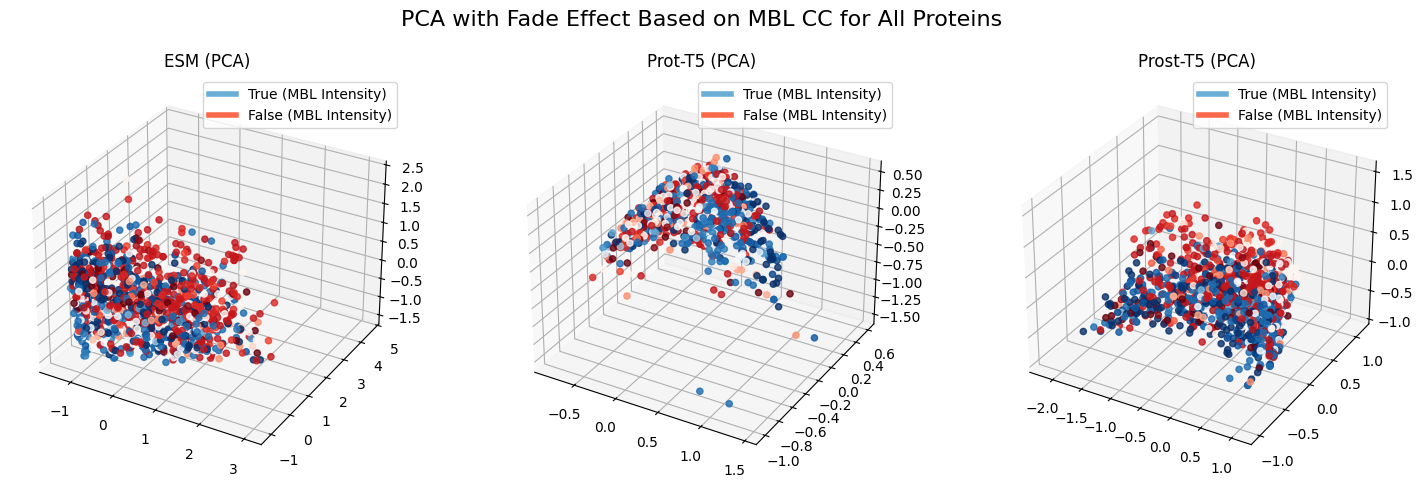

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

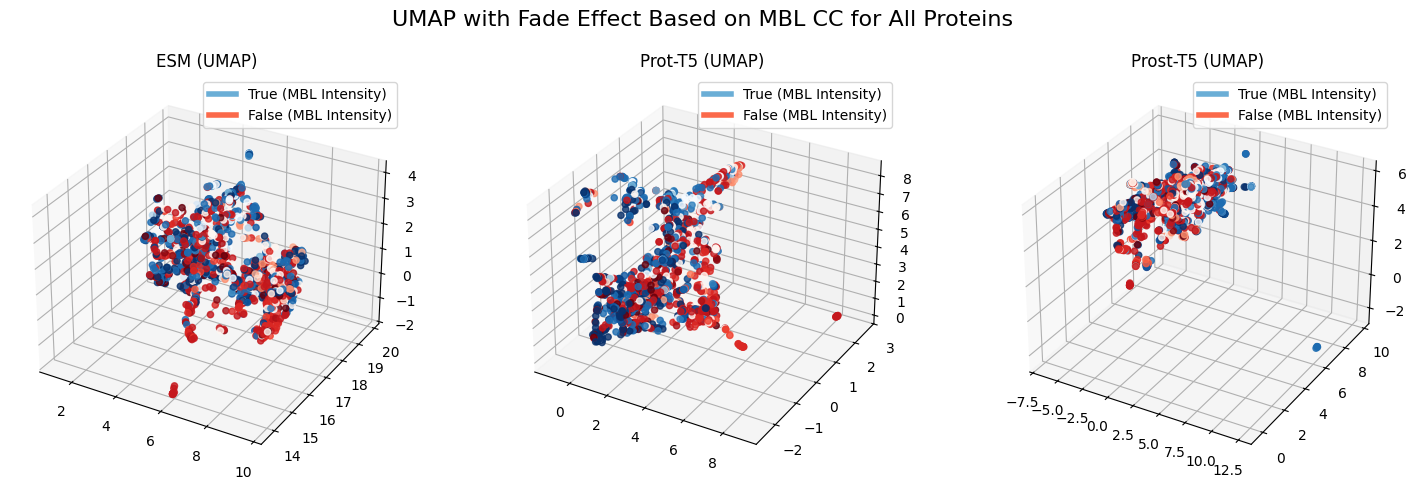

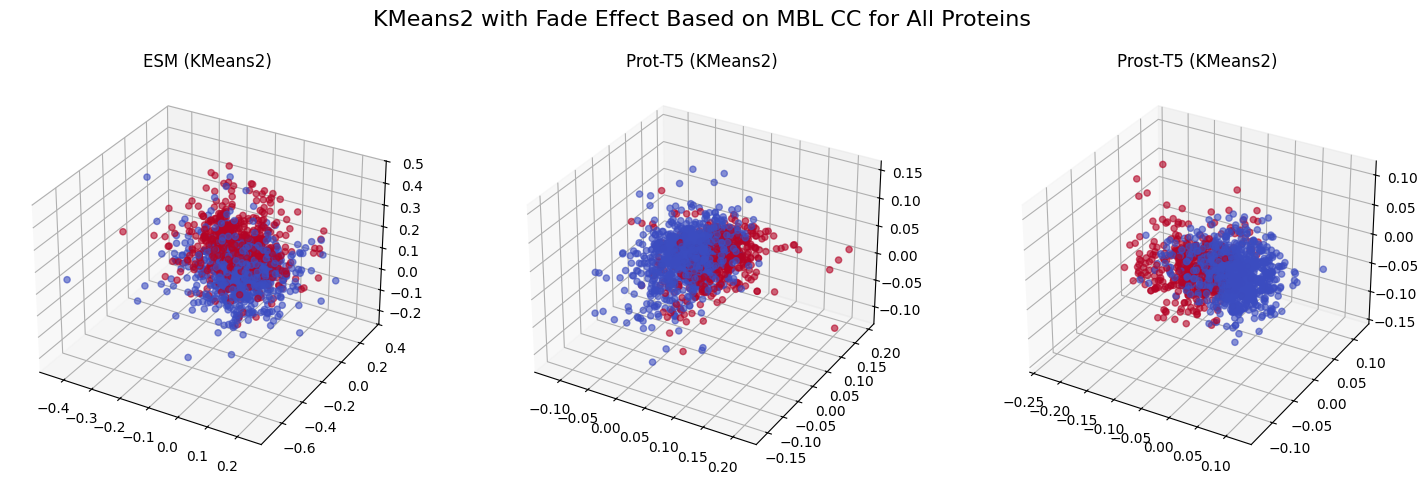

In [123]:
# Plot using the filtered data
for embedding_name in ['PCA', 'UMAP', 'KMeans2']:
    plots3D_with_fade_from_organized(
        method=embedding_name,
        organized_dfs=organized_dfs,
        mbl_col="c_max_mbl",  # Adjust if needed
        label_col="class",
        title=f"{embedding_name} with Fade Effect Based on MBL CC for All Proteins",
        save_img=True
    )

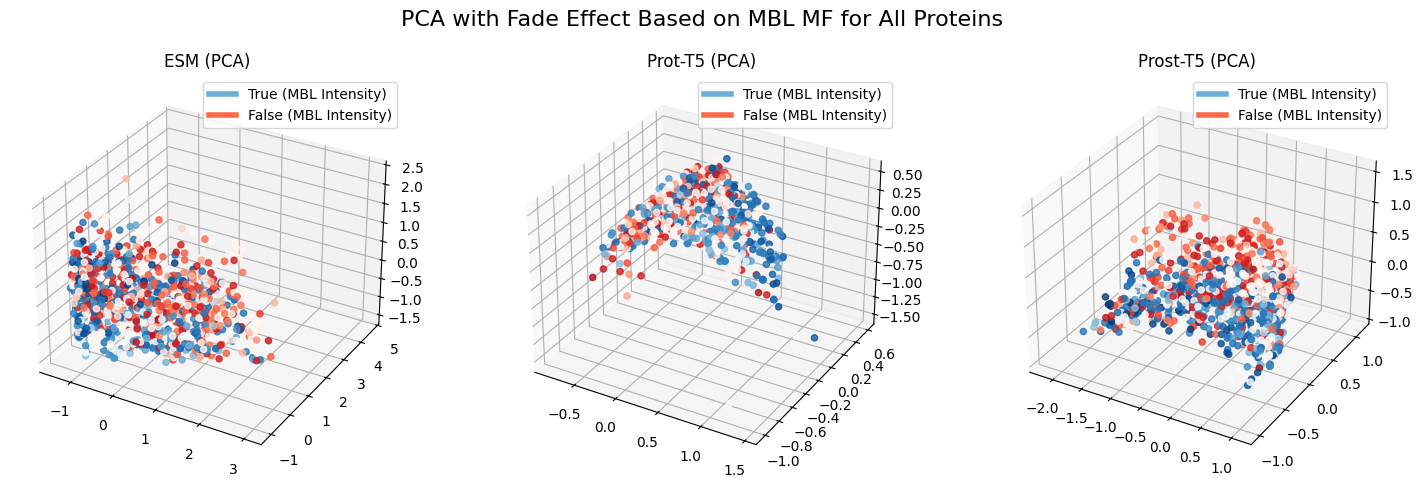

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

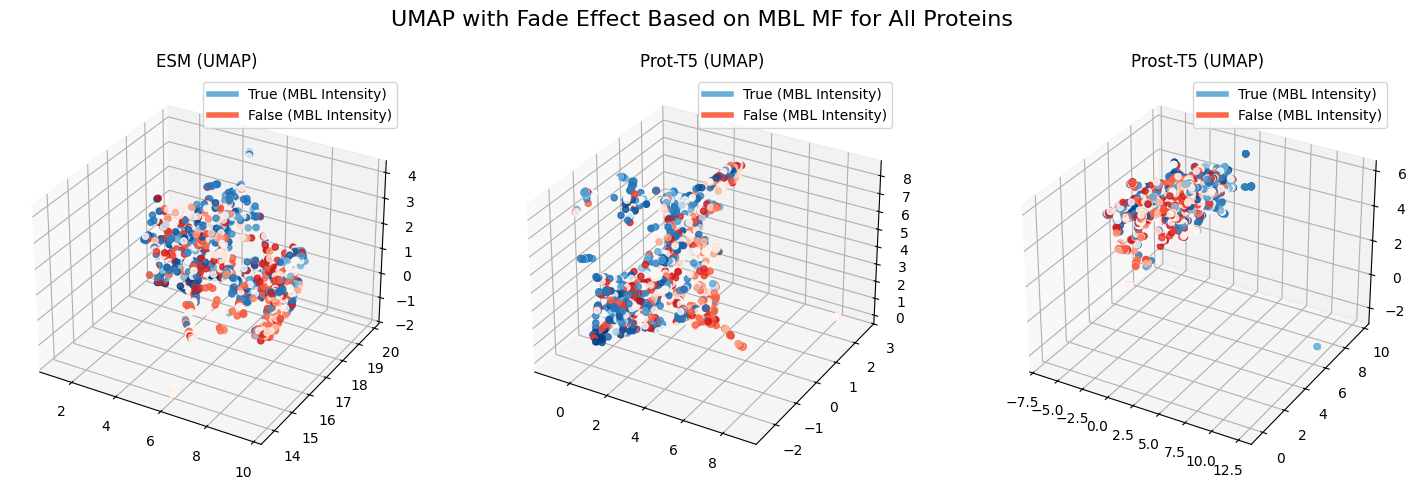

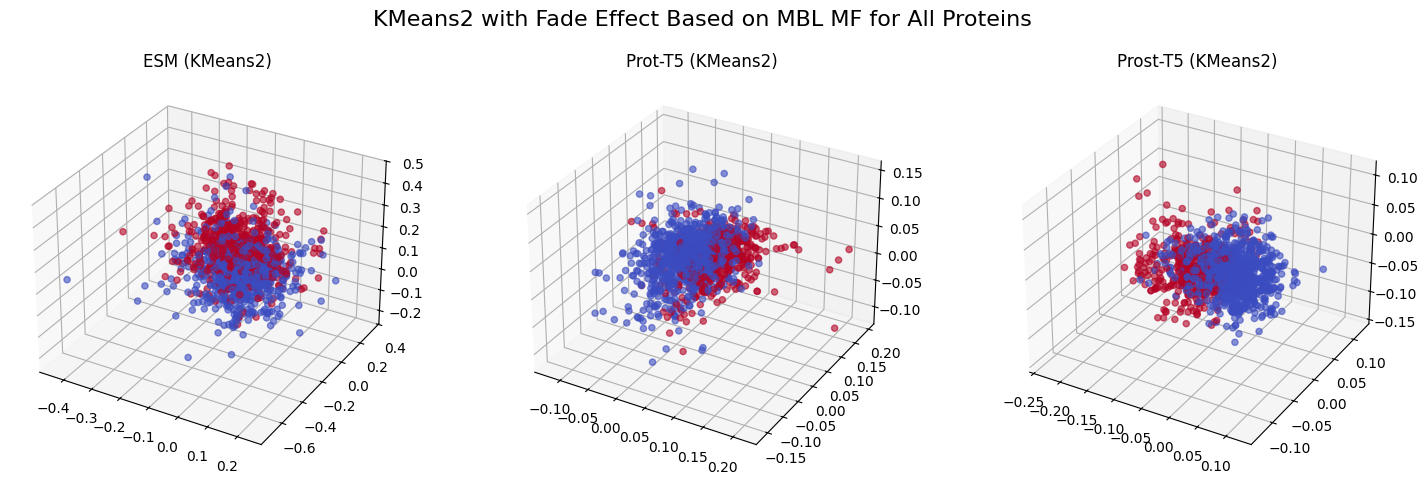

In [130]:
# Plot using the filtered data
for embedding_name in ['PCA', 'UMAP', 'KMeans2']:
    plots3D_with_fade_from_organized(
        method=embedding_name,
        organized_dfs=organized_dfs,
        mbl_col="f_max_mbl",  # Adjust if needed
        label_col="class",
        title=f"{embedding_name} with Fade Effect Based on MBL MF for All Proteins",
        save_img=True
    )

In [114]:
import re

# Clean the 'organism' column to remove text in brackets and trailing dots
organized_dfs["Features"]["organism"] = organized_dfs["Features"]["organism"].str.replace(r"\s*\(.*?\)\.", "", regex=True)

/var/folders/2v/ys7vsgms4tg4hgxr7s9cf3640000gn/T/ipykernel_65345/515366862.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  organized_dfs["Features"]["organism"] = organized_dfs["Features"]["organism"].str.replace(r"\s*\(.*?\)\.", "", regex=True)


In [127]:
# Define the top 4 organisms
top_4_organisms_list = [
    "Homo sapiens",
    "Mus musculus",
    "Escherichia coli",
    "Saccharomyces cerevisiae"
]

# Filter the Features DataFrame for the top 4 organisms
filtered_features = organized_dfs["Features"][organized_dfs["Features"]["organism"].isin(top_4_organisms_list)]

# Get the filtered indices
filtered_indices = filtered_features.index

# Reset the indices of the filtered features to align with NumPy arrays
filtered_features = filtered_features.reset_index(drop=True)

# Create filtered_organized_dfs with aligned indices
filtered_organized_dfs = {
    "Features": filtered_features,
    "ESM": organized_dfs["ESM"][filtered_indices],  # Select rows based on filtered indices
    "Prot-T5": organized_dfs["Prot-T5"][filtered_indices],
    "Prost-T5": organized_dfs["Prost-T5"][filtered_indices],
}

# Verify the shapes of the filtered embeddings
print(f"Filtered Features shape: {filtered_organized_dfs['Features'].shape}")
print(f"Filtered ESM shape: {filtered_organized_dfs['ESM'].shape}")
print(f"Filtered Prot-T5 shape: {filtered_organized_dfs['Prot-T5'].shape}")
print(f"Filtered Prost-T5 shape: {filtered_organized_dfs['Prost-T5'].shape}")

Filtered Features shape: (1000, 7)
Filtered ESM shape: (1000, 320)
Filtered Prot-T5 shape: (1000, 1024)
Filtered Prost-T5 shape: (1000, 1024)


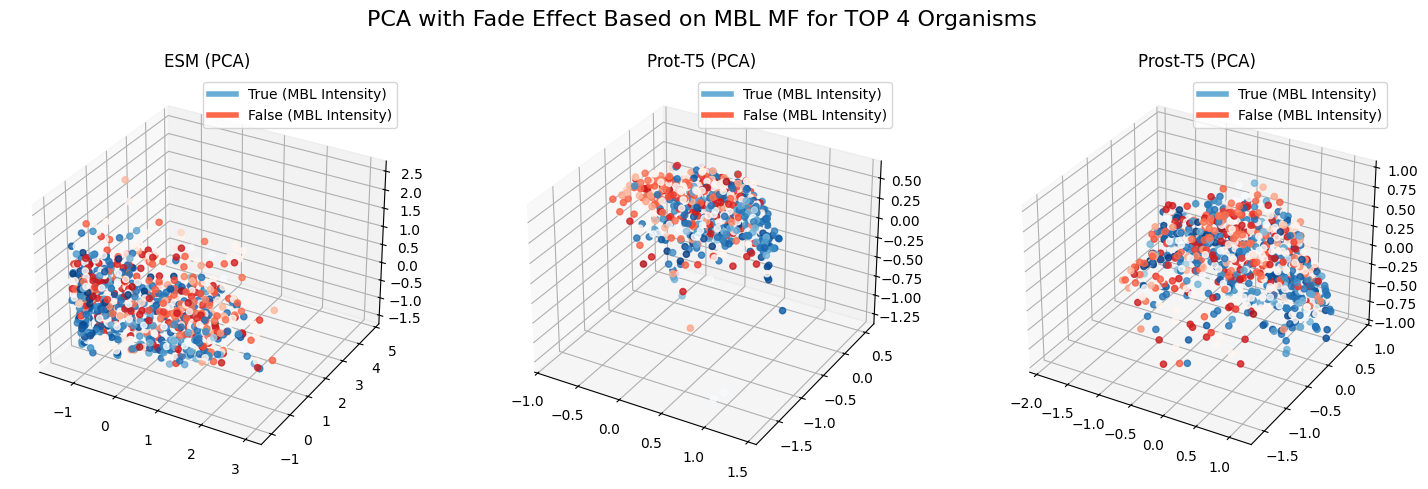

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

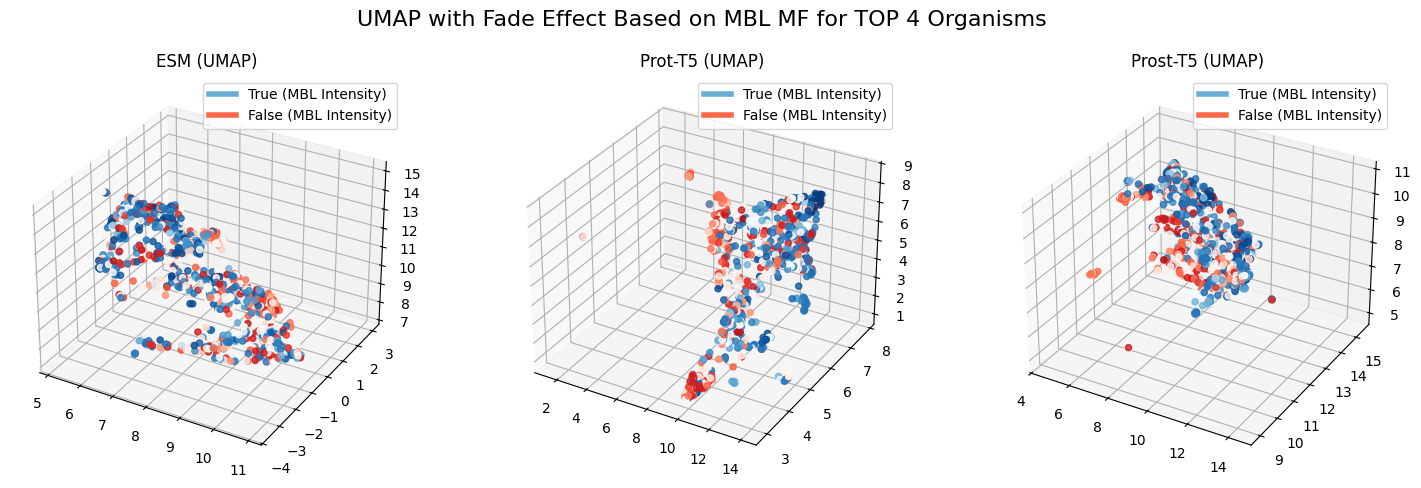

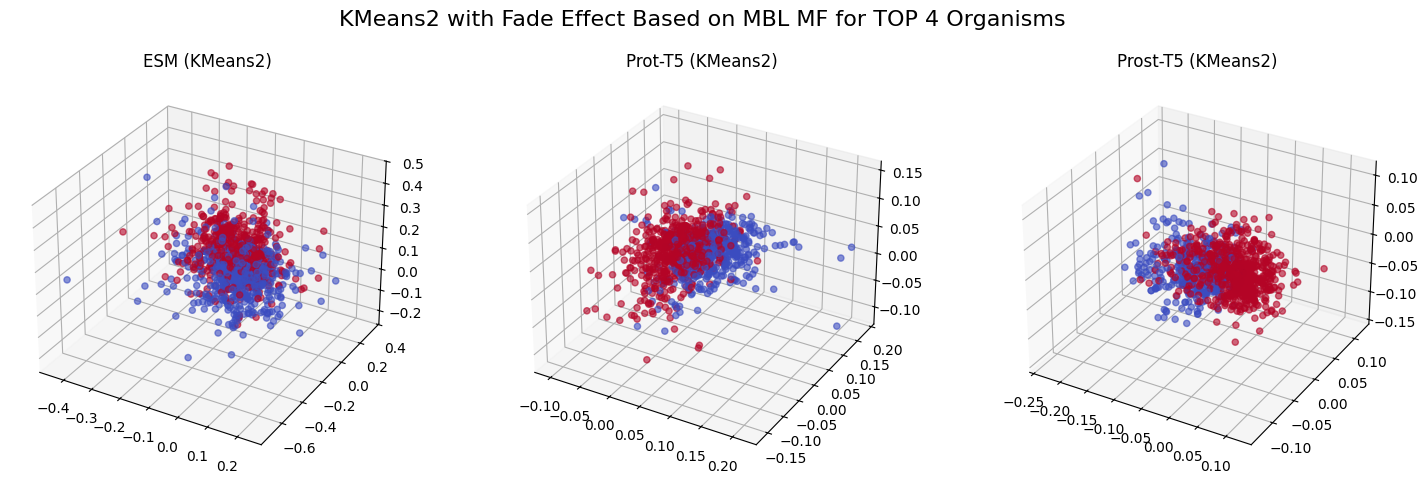

In [131]:
# Plot using the filtered data
for embedding_name in ['PCA', 'UMAP', 'KMeans2']:
    plots3D_with_fade_from_organized(
        method=embedding_name,
        organized_dfs=filtered_organized_dfs,
        mbl_col="f_max_mbl",  # Adjust if needed
        label_col="class",
        title=f"{embedding_name} with Fade Effect Based on MBL MF for TOP 4 Organisms",
        save_img=True
    )

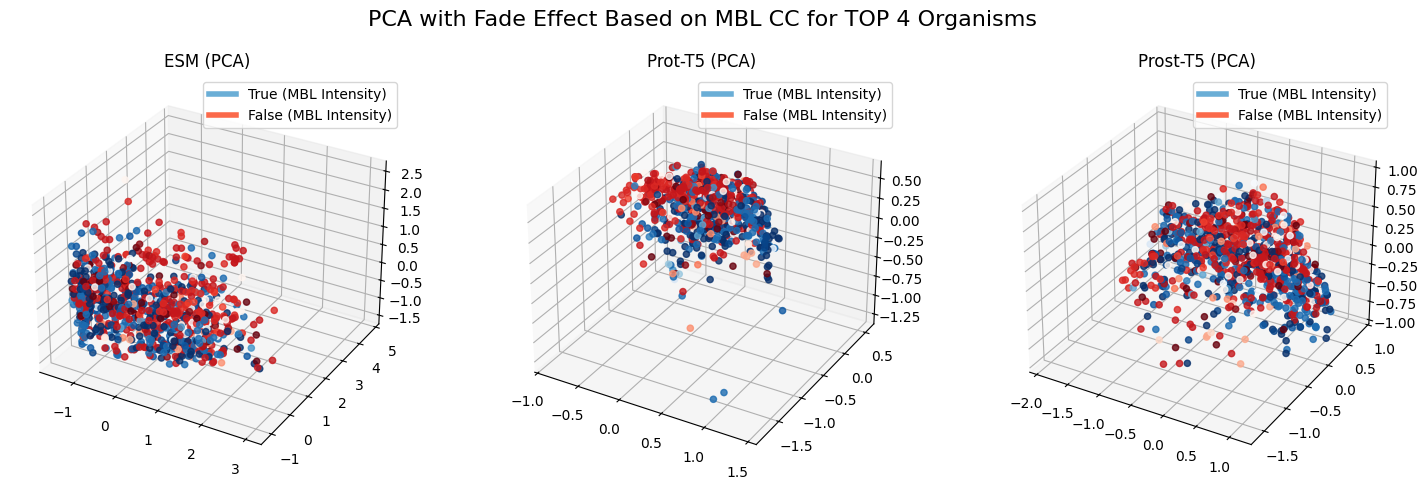

/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/alexdominguez/opt/anaconda3/envs/prott5-env/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: Futu

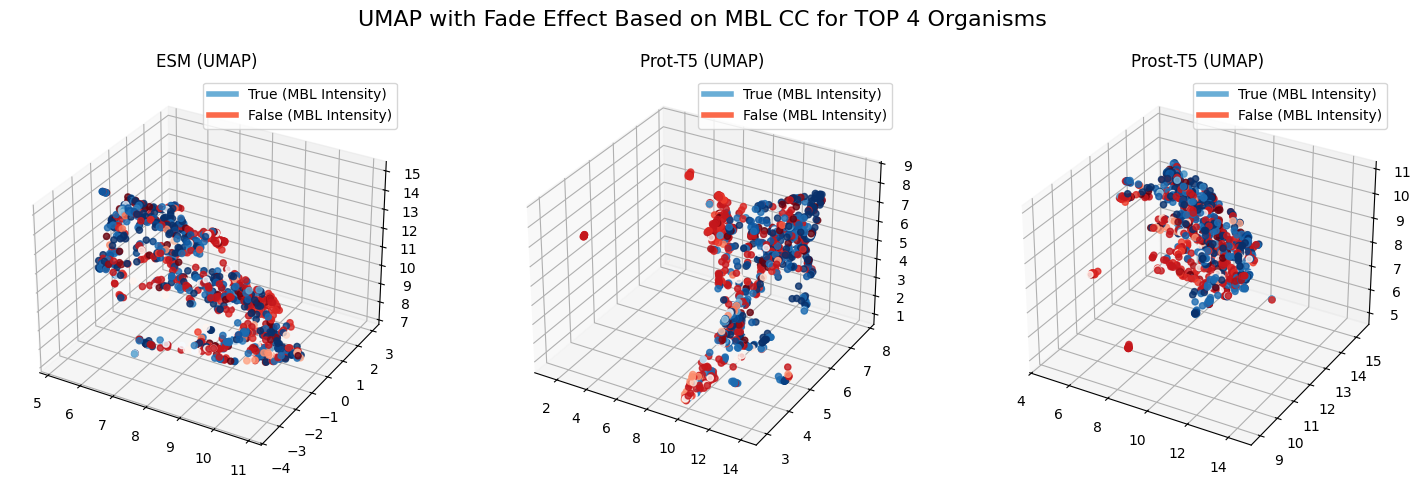

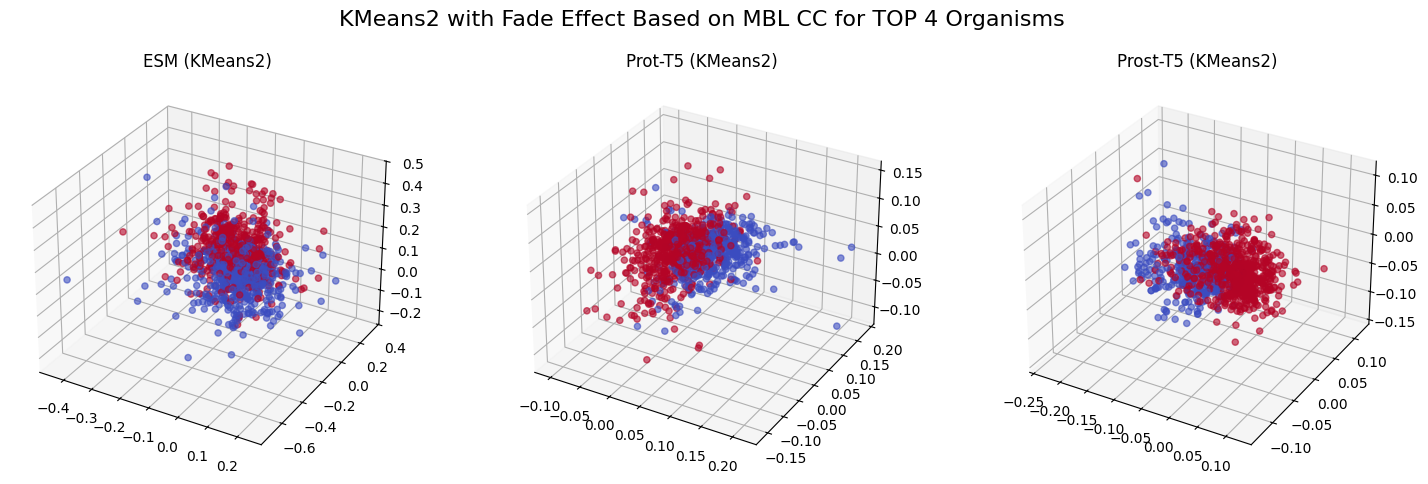

In [132]:
# Plot using the filtered data
for embedding_name in ['PCA', 'UMAP', 'KMeans2']:
    plots3D_with_fade_from_organized(
        method=embedding_name,
        organized_dfs=filtered_organized_dfs,
        mbl_col="c_max_mbl",  # Adjust if needed
        label_col="class",
        title=f"{embedding_name} with Fade Effect Based on MBL CC for TOP 4 Organisms",
        save_img=True
    )